<a href="https://colab.research.google.com/github/RyanO14/ENGPHYS-2NM4/blob/main/Assignments/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2



## Question 1

A nuclear fuel pellet is a cylinder, 1.5 cm in lenth and 1 cm in diameter. Assume the surface temperature is 300 C everywhere. Given temperature probe data below, determine the radial temperature profile in the middle of a nuclear fuel pellet (i.e.: T(r, z = 0.75)) using radial basis functions.


In [19]:
import numpy as np

# 20 data points presented in columns: | x | y | z | T |, measurements in cm

data = np.array([
    [5.1690e-02, 2.3766e-01, 6.7059e-01, 5.2645e+02],
    [1.1353e-01, 9.4708e-02, 5.3856e-01, 5.5201e+02],
    [1.6676e-01, 1.4358e-01, 4.6936e-01, 5.0802e+02],
    [1.3610e-01, 3.7207e-02, 2.1694e-01, 4.3663e+02],
    [8.9225e-02, 3.7293e-01, 1.1270e+00, 3.9234e+02],
    [1.9001e-01, 3.7240e-01, 8.4774e-01, 3.8872e+02],
    [5.4849e-02, 3.5425e-01, 5.7478e-01, 4.3784e+02],
    [1.7001e-01, 2.0241e-01, 1.2960e+00, 4.0159e+02],
    [2.0606e-01, 3.1594e-01, 6.4077e-01, 4.2652e+02],
    [2.5382e-01, 2.5859e-01, 4.8610e-01, 4.2481e+02],
    [5.6038e-02, 8.2231e-02, 4.2029e-01, 5.3244e+02],
    [3.1242e-01, 8.0489e-02, 1.1530e+00, 4.2453e+02],
    [6.0186e-02, 4.4891e-01, 3.9941e-01, 3.4207e+02],
    [1.5070e-01, 3.4794e-01, 1.5595e-01, 3.4750e+02],
    [1.8215e-01, 3.4388e-01, 1.0478e+00, 3.9963e+02],
    [1.1633e-01, 4.1011e-01, 5.5001e-01, 3.7611e+02],
    [1.2377e-01, 3.3703e-01, 3.7672e-02, 3.1423e+02],
    [4.6378e-02, 3.3653e-01, 1.4434e+00, 3.2345e+02],
    [2.9063e-02, 3.2584e-02, 2.3977e-01, 4.5993e+02],
    [2.1162e-02, 3.8590e-01, 2.5905e-01, 3.6901e+02]
])

Consider what you know about this system. What extra information do you have in terms of

### a) type(s) of symmetry?

This problem can be reduced into a one-dimensional radial temperature profile at the axial midpoint. There is no angle dependance and no [radial] slope at r = 0.

### b) Boundary conditions?

The given boundary condition is a fixed temperature of 300degC at every point on the pellet's surface. It can be assumed that the interior physics is symmetric about the pellet's middle plane.

## c) Plot the best guess of the radial temperature profile

Note: RBFs will fail with a linear solver error if two data points exactly overlap.

A Gaussian RBF approach can be used and applied to the pellet's cylindrical coordinates. First (x, y, z) coordinates can be changed to (r, z) because of the radial symmetry. Points of 300degC can be placed on the outer wall as both as both end faces. Then the RBF can be fit to all points and be evaluated along z = 0.75. Before fitting, any points with identical (r, z) coordindates can be combined to prevent the solver from returning an error. A smoothing term will also help this solver return a more numerically stable result.

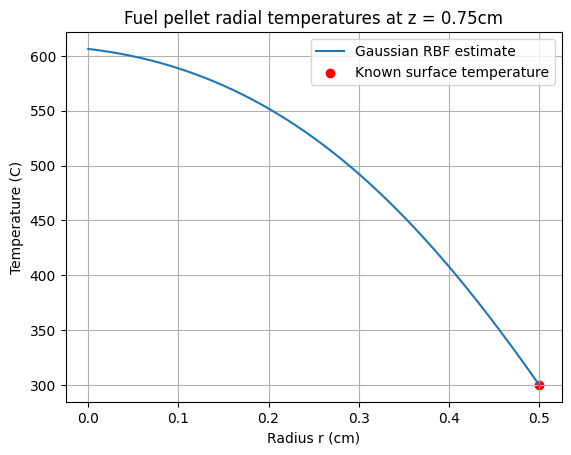

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from scipy.spatial.distance import pdist

#Dimensions, cm
R = 0.5
L = 1.5
T_surface = 300.0

# (x, y, z) to (r, z)
r_probe = np.hypot(data[:, 0], data[:, 1])
probe_points = np.column_stack((r_probe, data[:, 2]))
probe_temperatures = data[:, 3]

#Add boundary to wall and end faces
z_wall = np.linspace(0, L, 11)
r_face = np.linspace(0, R, 6)

wall_points = np.column_stack((
    np.full_like(z_wall, R),
    z_wall
))
bottom_points = np.column_stack((
    r_face,
    np.zeros_like(r_face)
))
top_points = np.column_stack((
    r_face,
    np.full_like(r_face, L)
))

boundary_points = np.vstack((
    wall_points, bottom_points, top_points
))
boundary_temperatures = np.full(
    len(boundary_points), T_surface
)

points = np.vstack((probe_points, boundary_points))
temperatures = np.concatenate((
    probe_temperatures, boundary_temperatures
))

#Merge overlapping points, if temperatures are different, use average
unique_points, inverse = np.unique(
    points, axis=0, return_inverse=True
)
unique_temperatures = (
    np.bincount(inverse, weights=temperatures)
    / np.bincount(inverse)
)

#RBF Solver
mean_distance = pdist(unique_points).mean()
epsilon = 1 / mean_distance

rbf = RBFInterpolator(
    unique_points,
    unique_temperatures,
    kernel='gaussian',
    epsilon=epsilon,
    smoothing=1e-5
)

#Evaluate at z = 0.75
r_plot = np.linspace(0, R, 300)
midplane_points = np.column_stack((
    r_plot,
    np.full_like(r_plot, L / 2)
))
T_plot = rbf(midplane_points)

#Evaluate at z = 0.75
r_plot = np.linspace(0, R, 300)
midplane_points = np.column_stack((
    r_plot,
    np.full_like(r_plot, L / 2)
))
T_plot = rbf(midplane_points)

plt.plot(r_plot, T_plot, label="Gaussian RBF estimate")
plt.scatter([R], [T_surface], color = 'red', label = 'Known surface temperature')
plt.xlabel("Radius r (cm)")
plt.ylabel("Temperature (C)")
plt.title("Fuel pellet radial temperatures at z = 0.75cm")
plt.grid(True)
plt.legend()
plt.show()

The plotted curve is an RBF-based estimate of the temperature variation from the centreline of the fuel pellet to its outside surface at the middle height, z = 0.75cm. The temperature is expected to be highest near the center because the outside is to remain at 300C. This result is physically reasonable, as the heat generated in the pellet interior must conduct outward to the cooler fixed-temperature surface.


# Question 2

You run an experiment and obtain the following data:

| x | y1 | y2 | y3 | y4 | y5 |
|---|---|---|---| --- | --- |
| 0.00 | -29.49 | -2.14 | 15.88 | 22.69 | 28.53 |
| 1.11 | 2.83 | 18.02 | -25.45 | -32.45 | 7.50 |
| 2.22 | 1.97 | -10.49 | -0.18 | -32.10 | -40.31 |
| 3.33 | -38.09 | -46.16 | -7.87 | -33.97 | -38.39 |
| 4.44 | -3.97 | -32.22 | -33.95 | -11.07 | -32.47 |
| 5.56 | 4.45 | -10.88 | 20.43 | 6.57 | -8.49 |
| 6.67 | 50.22 | 51.29 | 80.02 | 66.15 | 84.90 |
| 7.78 | 164.11 | 190.26 | 160.94 | 182.35 | 163.18 |
| 8.89 | 331.75 | 306.51 | 278.40 | 302.13 | 335.44 |
| 10.00 | 517.06 | 483.20 | 476.73 | 512.16 | 500.64 |



In [21]:
import numpy as np

# Define the table as a list of lists
d = np.array([
    [0.00, -29.49, -2.14, 15.88, 22.69, 28.53],
    [1.11, 2.83, 18.02, -25.45, -32.45, 7.50],
    [2.22, 1.97, -10.49, -0.18, -32.10, -40.31],
    [3.33, -38.09, -46.16, -7.87, -33.97, -38.39],
    [4.44, -3.97, -32.22, -33.95, -11.07, -32.47],
    [5.56, 4.45, -10.88, 20.43, 6.57, -8.49],
    [6.67, 50.22, 51.29, 80.02, 66.15, 84.90],
    [7.78, 164.11, 190.26, 160.94, 182.35, 163.18],
    [8.89, 331.75, 306.51, 278.40, 302.13, 335.44],
    [10.00, 517.06, 483.20, 476.73, 512.16, 500.64]
])

## a) Determine the best cubic polynomial fit to this data with the uncertainty

For each xi, the mean and standard deviation of the 5 measurements can be calculated. The mean values represent the measured trend, while the standard deviations represent the uncertainty at each xi. A cubic model can be fitted to the mean values using least squares. The fit can be weighted by the measurement uncertainty using weights wi = 1/si^2. The uncertainty bands can be shown as avg(yi) +/- si.

REPEATED-MEASUREMENT STATISTICS
 x       mean       std dev       SEM        min        max
 0.00       7.094      23.471      10.497     -29.490      28.530
 1.11      -5.910      21.881       9.785     -32.450      18.020
 2.22     -16.222      19.062       8.525     -40.310       1.970
 3.33     -32.896      14.668       6.560     -46.160      -7.870
 4.44     -22.736      14.131       6.319     -33.950      -3.970
 5.56       2.416      12.665       5.664     -10.880      20.430
 6.67      66.516      15.952       7.134      50.220      84.900
 7.78     172.168      13.255       5.928     160.940     190.260
 8.89     310.846      23.395      10.463     278.400     335.440
10.00     497.958      17.622       7.881     476.730     517.060

INDIVIDUAL CUBIC FITS

y1(x) = 1.395897x^3 -10.533483x^2 +20.679798x -20.518748
  SSE  = 1681.9602
  MSE  = 280.3267
  RMSE = 16.7430
  R^2  = 0.994558

y2(x) = 0.858367x^3 -2.094325x^2 -16.948545x +14.655651
  SSE  = 2596.8558
  MSE  = 432.8093
 

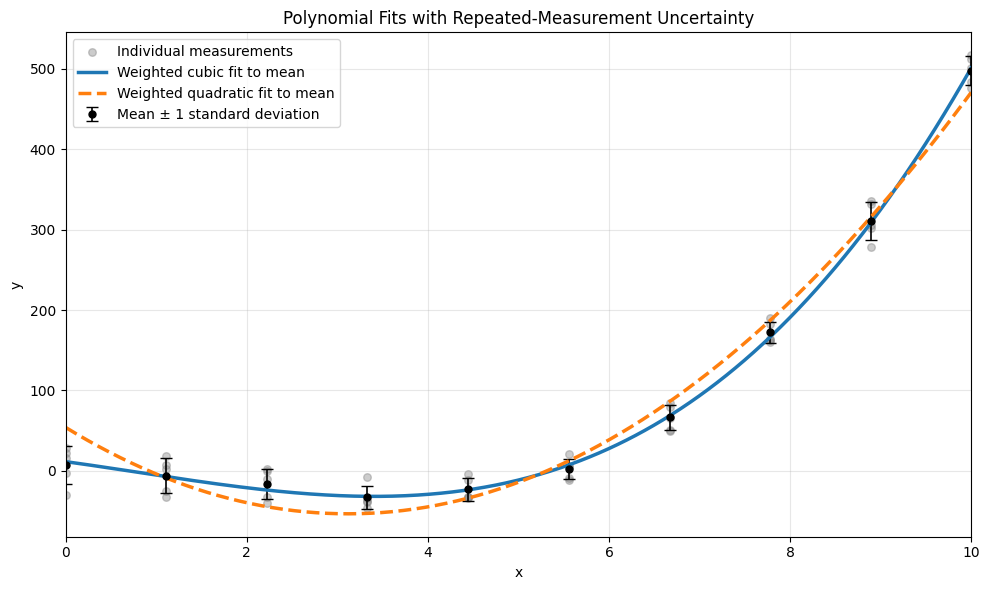

In [23]:
x = d[:, 0]
y = d[:, 1:]       # Shape: (10, 5), columns are y1 to y5

n = len(x)
p_cubic = 4
dof_cubic = n - p_cubic

# Smooth x-values for drawing fitted curves
x_plot = np.linspace(x.min(), x.max(), 500)

# REPEATED-MEASUREMENT STATISTICS AT EACH x VALUE


y_mean = np.mean(y, axis=1)
y_std = np.std(y, axis=1, ddof=1)             # Sample standard deviation
y_sem = y_std / np.sqrt(y.shape[1])           # Standard error of the mean
y_min = np.min(y, axis=1)
y_max = np.max(y, axis=1)

print("REPEATED-MEASUREMENT STATISTICS")
print(" x       mean       std dev       SEM        min        max")
for i in range(n):
    print(
        f"{x[i]:5.2f}  "
        f"{y_mean[i]:10.3f}  "
        f"{y_std[i]:10.3f}  "
        f"{y_sem[i]:10.3f}  "
        f"{y_min[i]:10.3f}  "
        f"{y_max[i]:10.3f}"
    )

# CUBIC FIT TO EACH INDIVIDUAL DATASET: y1, y2, ..., y5

cubic_coefficients = []
individual_SSE = []
individual_MSE = []
individual_RMSE = []
individual_R2 = []
individual_residuals = []

print("\n" + "=" * 70)
print("INDIVIDUAL CUBIC FITS")
print("=" * 70)

for j in range(y.shape[1]):
    yj =y[:, j]

    # Returns [a3, a2, a1, a0] for a3*x^3 + a2*x^2 + a1*x + a0
    coeffs = np.polyfit(x, yj, deg=3)
    cubic_coefficients.append(coeffs)

    # Predictions and residuals at the original data points
    yj_pred = np.polyval(coeffs, x)
    residuals = yj - yj_pred

    # Error calculations
    SSE = np.sum(residuals**2)
    MSE = SSE / dof_cubic
    RMSE = np.sqrt(MSE)

    # R^2: fraction of the dataset variation explained by the cubic
    SST = np.sum((yj - np.mean(yj))**2)
    R2 = 1 - SSE / SST

    individual_SSE.append(SSE)
    individual_MSE.append(MSE)
    individual_RMSE.append(RMSE)
    individual_R2.append(R2)
    individual_residuals.append(residuals)

    a3, a2, a1, a0 = coeffs

    print(f"\ny{j + 1}(x) = "
          f"{a3:.6f}x^3 "
          f"{a2:+.6f}x^2 "
          f"{a1:+.6f}x "
          f"{a0:+.6f}")

    print(f"  SSE  = {SSE:.4f}")
    print(f"  MSE  = {MSE:.4f}")
    print(f"  RMSE = {RMSE:.4f}")
    print(f"  R^2  = {R2:.6f}")

cubic_coefficients = np.array(cubic_coefficients)
individual_SSE = np.array(individual_SSE)
individual_MSE = np.array(individual_MSE)
individual_RMSE = np.array(individual_RMSE)
individual_R2 = np.array(individual_R2)
individual_residuals = np.array(individual_residuals)

# CUBIC FIT TO THE MEAN OF THE FIVE DATASETS. This is a useful single "best estimate" curve with uncertainty.

# A point with lower SEM receives greater fitting weight.
mean_cubic_coefficients = np.polyfit(
    x,
    y_mean,
    deg=3,
    w=1 / y_sem
)

mean_cubic_prediction = np.polyval(mean_cubic_coefficients, x)
mean_cubic_residuals = y_mean - mean_cubic_prediction

mean_cubic_SSE = np.sum(mean_cubic_residuals**2)
mean_cubic_weighted_SSE = np.sum((mean_cubic_residuals / y_sem)**2)
mean_cubic_MSE = mean_cubic_SSE / dof_cubic
mean_cubic_RMSE = np.sqrt(mean_cubic_MSE)

mean_SST = np.sum((y_mean - np.mean(y_mean))**2)
mean_cubic_R2 = 1 - mean_cubic_SSE / mean_SST

a3, a2, a1, a0 = mean_cubic_coefficients

print("\n" + "=" * 70)
print("WEIGHTED CUBIC FIT TO THE MEAN DATA")
print("=" * 70)
print(f"\ny_mean(x) = "
      f"{a3:.6f}x^3 "
      f"{a2:+.6f}x^2 "
      f"{a1:+.6f}x "
      f"{a0:+.6f}")

print(f"\nUnweighted SSE = {mean_cubic_SSE:.4f}")
print(f"Weighted SSE (chi-square) = {mean_cubic_weighted_SSE:.4f}")
print(f"MSE = {mean_cubic_MSE:.4f}")
print(f"RMSE = {mean_cubic_RMSE:.4f}")
print(f"R^2 = {mean_cubic_R2:.6f}")

# QUADRATIC FIT TO THE MEAN DATA FOR PART (b)

p_quadratic = 3
dof_quadratic = n - p_quadratic

mean_quadratic_coefficients = np.polyfit(
    x,
    y_mean,
    deg=2,
    w=1 / y_sem
)

mean_quadratic_prediction = np.polyval(
    mean_quadratic_coefficients, x
)
mean_quadratic_residuals = y_mean - mean_quadratic_prediction

mean_quadratic_SSE = np.sum(mean_quadratic_residuals**2)
mean_quadratic_weighted_SSE = np.sum(
    (mean_quadratic_residuals / y_sem)**2
)
mean_quadratic_MSE = mean_quadratic_SSE / dof_quadratic
mean_quadratic_RMSE = np.sqrt(mean_quadratic_MSE)

mean_quadratic_SST = np.sum((y_mean - np.mean(y_mean))**2)
mean_quadratic_R2 = 1 - mean_quadratic_SSE / mean_quadratic_SST

a2, a1, a0 = mean_quadratic_coefficients

print("\n" + "=" * 70)
print("WEIGHTED QUADRATIC FIT TO THE MEAN DATA")
print("=" * 70)
print(f"\ny_mean(x) = "
      f"{a2:.6f}x^2 "
      f"{a1:+.6f}x "
      f"{a0:+.6f}")

print(f"\nUnweighted SSE = {mean_quadratic_SSE:.4f}")
print(f"Weighted SSE (chi-square) = {mean_quadratic_weighted_SSE:.4f}")
print(f"MSE = {mean_quadratic_MSE:.4f}")
print(f"RMSE = {mean_quadratic_RMSE:.4f}")
print(f"R^2 = {mean_quadratic_R2:.6f}")

# PLOT: ALL RAW DATA, MEAN ± 1 STANDARD DEVIATION,

plt.figure(figsize=(10, 6))

# Individual repeated measurements
for j in range(y.shape[1]):
    plt.scatter(
        x,
        y[:, j],
        color="gray",
        alpha=0.40,
        s=30,
        label="Individual measurements" if j == 0 else None
    )

# Mean and uncertainty
plt.errorbar(
    x,
    y_mean,
    yerr=y_std,
    fmt="o",
    color="black",
    markersize=5,
    capsize=4,
    linewidth=1.2,
    label="Mean ± 1 standard deviation"
)

# Fitted curves to mean values
plt.plot(
    x_plot,
    np.polyval(mean_cubic_coefficients, x_plot),
    color="tab:blue",
    linewidth=2.5,
    label="Weighted cubic fit to mean"
)

plt.plot(
    x_plot,
    np.polyval(mean_quadratic_coefficients, x_plot),
    color="tab:orange",
    linestyle="--",
    linewidth=2.5,
    label="Weighted quadratic fit to mean"
)

plt.xlim(x.min(), x.max())
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Fits with Repeated-Measurement Uncertainty")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

"""
x = d[:, 0]
y = d[:, 1:]

# Mean and sample standard deviation at each x
y_mean = np.mean(y, axis=1)
y_std = np.std(y, axis=1, ddof=1)

# Cubic weighted least-squares fit
cubic_coefficients = np.polyfit(
    x,
    y_mean,
    deg=3,
    w=1 / y_std
)

# Quadratic weighted least-squares fit
quadratic_coefficients = np.polyfit(
    x,
    y_mean,
    deg=2,
    w=1 / y_std
)

# Smooth curves for plotting
x_plot = np.linspace(x.min(), x.max(), 500)
y_cubic = np.polyval(cubic_coefficients, x_plot)
y_quadratic = np.polyval(quadratic_coefficients, x_plot)

# Plot measurements, uncertainty, and fits
plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y_mean,
    yerr=y_std,
    fmt="o",
    capsize=4,
    label="Mean measurement ± 1 standard deviation"
)

plt.plot(
    x_plot,
    y_cubic,
    label="Weighted cubic fit",
    linewidth=2
)

plt.plot(
    x_plot,
    y_quadratic,
    "--",
    label="Weighted quadratic fit",
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial fits to experimental data")
plt.grid(True)
plt.legend()
plt.show()

# Print coefficients
print("Cubic coefficients [a3, a2, a1, a0]:")
print(cubic_coefficients)

print("\nQuadratic coefficients [a2, a1, a0]:")
print(quadratic_coefficients)

# Weighted residual sums of squares
cubic_residual = np.sum(
    ((y_mean - np.polyval(cubic_coefficients, x)) / y_std)**2
)

quadratic_residual = np.sum(
    ((y_mean - np.polyval(quadratic_coefficients, x)) / y_std)**2
)

print("\nWeighted cubic residual:", cubic_residual)
print("Weighted quadratic residual:", quadratic_residual)
"""


## b) Your manager thinks this should be a quadratic. Which do you think it should be and why?

{Answer}